# Deep Learning-Based Forecasting of Live Birth Trends in England and Wales

Research Question: How effectively can deep learning models forecast live birth counts from long-term demographic time-series data?
Dataset Location : https://www.ons.gov.uk/peoplepopulationandcommunity/birthsdeathsandmarriages/livebirths/bulletins/birthsummarytablesenglandandwales/2024refreshedpopulations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('birthrates.csv')

In [13]:
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Indicator Name,Indicator Code,Country Name,Country Code,Year,Value,Disaggregation
0,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,Africa Eastern and Southern,AFE,2023,32.955,NaN
1,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,Africa Eastern and Southern,AFE,2022,33.320,NaN
2,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,Africa Eastern and Southern,AFE,2021,33.681,NaN
3,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,Africa Eastern and Southern,AFE,2020,34.010,NaN
4,"Birth rate, crude (per 1,000 people)",SP.DYN.CBRT.IN,Africa Eastern and Southern,AFE,2019,34.336,NaN


In [15]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16930 entries, 0 to 16929
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Indicator Name  16930 non-null  object 
 1   Indicator Code  16930 non-null  object 
 2   Country Name    16930 non-null  object 
 3   Country Code    16930 non-null  object 
 4   Year            16930 non-null  int64  
 5   Value           16930 non-null  float64
 6   Disaggregation  0 non-null      float64
dtypes: float64(2), int64(1), object(4)
memory usage: 926.0+ KB


In [16]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Indicator Name        0
Indicator Code        0
Country Name          0
Country Code          0
Year                  0
Value                 0
Disaggregation    16930
dtype: int64


In [23]:
print("Final prepared DataFrame for time series analysis:")
print(df_filtered.head())


Final prepared DataFrame for time series analysis:
      Birth Rate
Year            
1960        17.5
1961        17.9
1962        18.3
1963        18.5
1964        18.8


In [24]:
print("\nInformation about the final DataFrame:")
df_filtered.info()


Information about the final DataFrame:
<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 1960 to 2023
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Birth Rate  64 non-null     float64
dtypes: float64(1)
memory usage: 1.0 KB


In [26]:
df_filtered = df[df['Country Name'] == 'United Kingdom'].copy()
df_filtered.drop(columns=['Disaggregation', 'Indicator Name', 'Indicator Code', 'Country Code'], inplace=True)
df_filtered.rename(columns={'Value': 'Birth Rate'}, inplace=True)


In [28]:
print("Filtered and Cleaned Data for United Kingdom (representing England and Wales):")
print(df_filtered.head())

Filtered and Cleaned Data for United Kingdom (representing England and Wales):
         Country Name  Year  Birth Rate
16192  United Kingdom  2023      10.023
16193  United Kingdom  2022      10.100
16194  United Kingdom  2021      10.241
16195  United Kingdom  2020      10.204
16196  United Kingdom  2019      10.645


In [29]:
print("\nInformation about the filtered data:")
df_filtered.info()


Information about the filtered data:
<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 16192 to 16255
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  64 non-null     object 
 1   Year          64 non-null     int64  
 2   Birth Rate    64 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.0+ KB


In [30]:
print("\nMissing values in filtered data:")
print(df_filtered.isnull().sum())


Missing values in filtered data:
Country Name    0
Year            0
Birth Rate      0
dtype: int64


# **EDA**

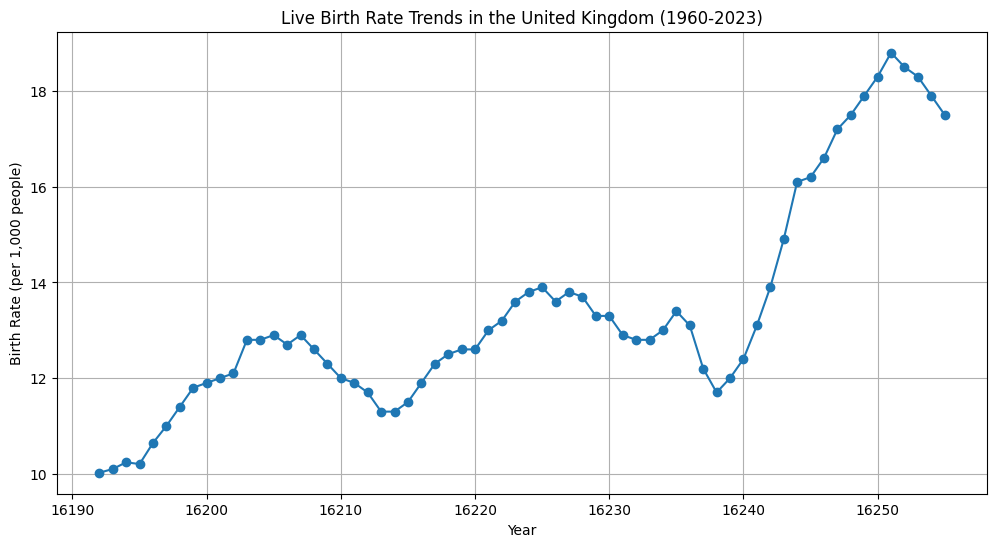

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df_filtered.index, df_filtered['Birth Rate'], marker='o', linestyle='-')
plt.title('Live Birth Rate Trends in the United Kingdom (1960-2023)')
plt.xlabel('Year')
plt.ylabel('Birth Rate (per 1,000 people)')
plt.grid(True)
plt.show()

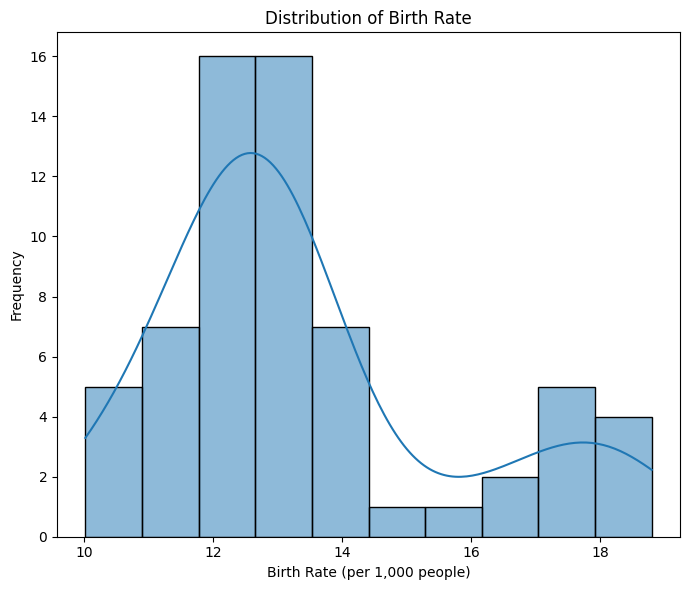

In [35]:
plt.figure(figsize=(7, 6))

# Histogram
sns.histplot(df_filtered['Birth Rate'], kde=True, bins=10)
plt.title('Distribution of Birth Rate')
plt.xlabel('Birth Rate (per 1,000 people)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

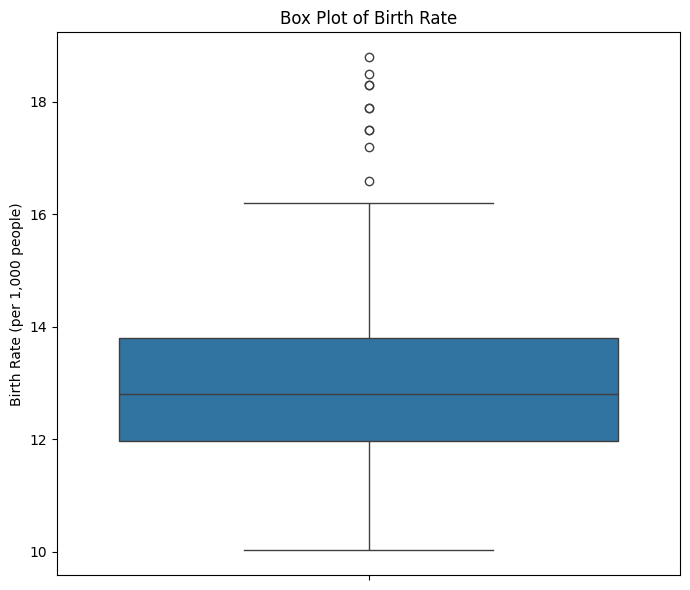

In [38]:
plt.figure(figsize=(7, 6))

# Box Plot
sns.boxplot(y=df_filtered['Birth Rate'])
plt.title('Box Plot of Birth Rate')
plt.ylabel('Birth Rate (per 1,000 people)')

plt.tight_layout()
plt.show()

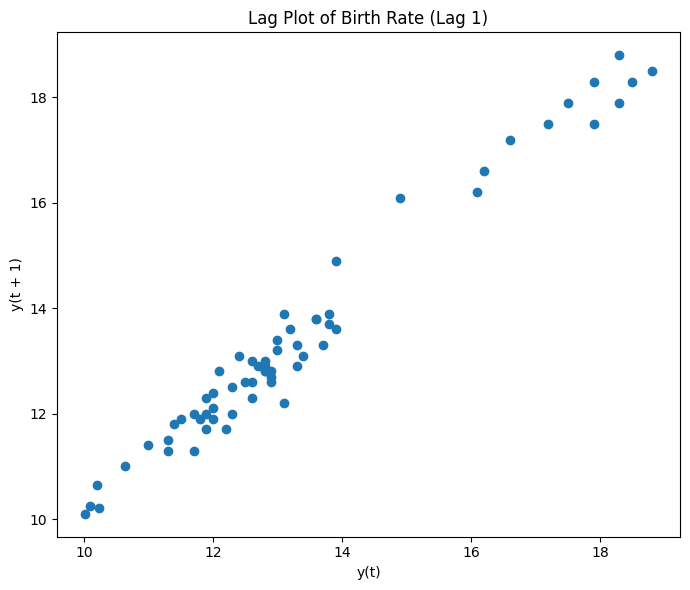

In [36]:
from pandas.plotting import lag_plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# Lag Plot (Lag 1)
lag_plot(df_filtered['Birth Rate'], lag=1)
plt.title('Lag Plot of Birth Rate (Lag 1)')

plt.tight_layout()
plt.show()

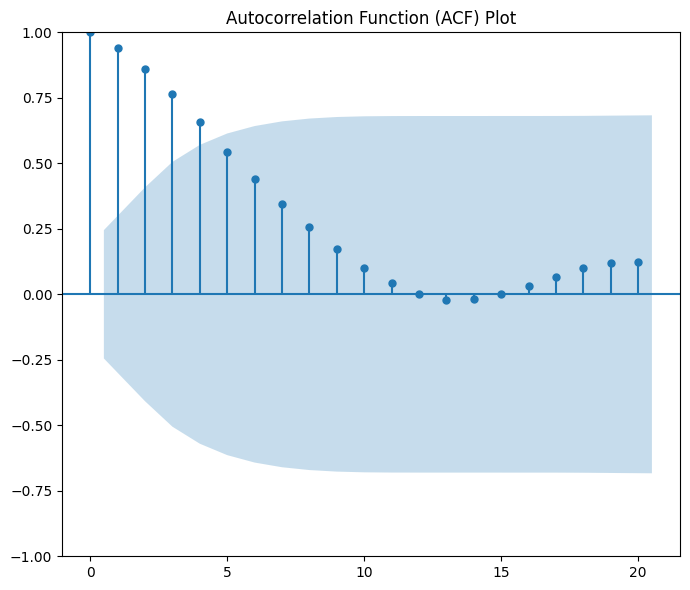

In [39]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# ACF Plot
plot_acf(df_filtered['Birth Rate'], lags=min(20, len(df_filtered) - 1), ax=plt.gca())
plt.title('Autocorrelation Function (ACF) Plot')

plt.tight_layout()
plt.show()